In [ ]:
!pip install efficientnet_pytorch

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from efficientnet_pytorch import EfficientNet
from PIL import Image
import json
import requests
from google.colab import drive

# Google Drive 마운트
drive.mount('/content/drive')

Mounted at /content/drive


1. efficientnet-b0 모델

In [4]:
# 이미지 경로
image_path = '/content/drive/MyDrive/Boaz/session/data/imgs/'

# ImageNet 클래스 매핑
imagenet_json_path = '/content/drive/MyDrive/Boaz/session/data/imagenet.json'

with open(imagenet_json_path, "r") as f:
    imagenet_classes = json.load(f)

# efficientnet-b0 모델 로드
model1 = EfficientNet.from_pretrained('efficientnet-b0')
model1.eval()


def preprocess_image(image_path, image_size):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  #사이즈 맞게 정리
    ])

    image = Image.open(image_path).convert('RGB')  #PIL 이미지로 변환
    image = transform(image)
    image = image.unsqueeze(0)  #배치 차원 수정

    return image

#추론 함수
def inference(model, image_path):
    image_size = model._conv_stem.weight.shape[2]
    input_tensor = preprocess_image(image_path, image_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    input_tensor = input_tensor.to(device)

    # 추론 수행
    with torch.no_grad():
        output = model(input_tensor)

    # 결과 해석
    probabilities = torch.nn.functional.softmax(output[0], dim=0)  # 소프트맥스 적용
    top5_prob, top5_catid = torch.topk(probabilities, 5)  # 상위 5개 클래스 추출

    for i in range(5):
        class_idx = str(top5_catid[i].item())
        class_name = imagenet_classes[class_idx][1]
        print(f"{class_name}: {top5_prob[i].item() * 100:.2f}%")

    # 원본 이미지 출력
    image = Image.open(image_path)
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth
100%|██████████| 20.4M/20.4M [00:00<00:00, 156MB/s]


Loaded pretrained weights for efficientnet-b0


palace: 36.16%
castle: 24.67%
church: 8.73%
bell_cote: 7.13%
monastery: 2.25%


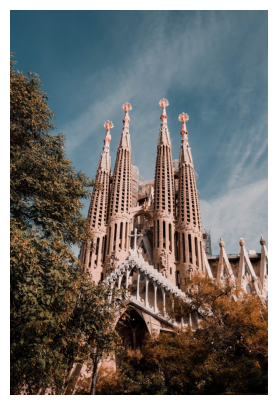

In [5]:
# 이미지 1 실행
inference(model1, image_path+"image01.jpg")

breakwater: 56.29%
lakeside: 4.80%
maze: 3.65%
seashore: 2.23%
patio: 1.52%


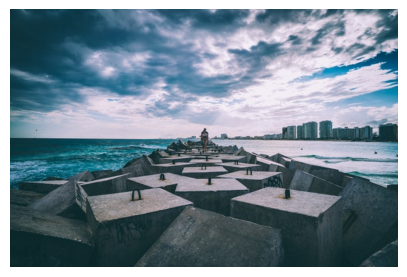

In [6]:
# 이미지 2 실행
inference(model1, image_path+"image02.jpg")

Labrador_retriever: 68.24%
golden_retriever: 24.84%
beagle: 0.34%
Chesapeake_Bay_retriever: 0.27%
tennis_ball: 0.21%


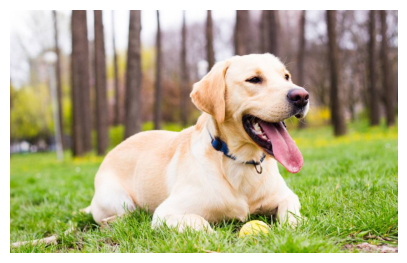

In [7]:
# 이미지 3 실행
inference(model1, image_path+"image03.jpg")

Egyptian_cat: 46.60%
lynx: 10.29%
tabby: 4.45%
tiger_cat: 3.83%
Persian_cat: 2.07%


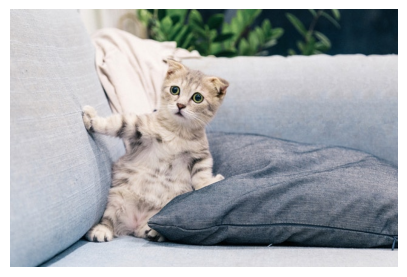

In [8]:
# 이미지 4 실행
inference(model1, image_path+"image04.jpg")

2. efficientnet-b7 모델

In [14]:
model2 = EfficientNet.from_pretrained('efficientnet-b7')
model2.eval()

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b7-dcc49843.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b7-dcc49843.pth
100%|██████████| 254M/254M [00:01<00:00, 212MB/s]


Loaded pretrained weights for efficientnet-b7


EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        64, 16, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        16, 64, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False
  

church: 58.05%
palace: 18.72%
castle: 8.39%
bell_cote: 3.78%
monastery: 2.00%


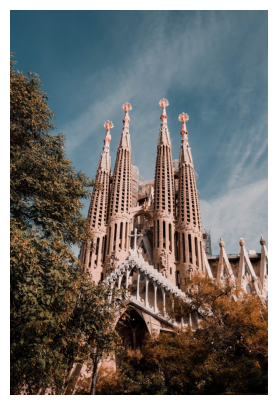

In [15]:
# 이미지 1 실행
inference(model2, image_path+"image01.jpg")

breakwater: 79.23%
maze: 6.20%
seashore: 0.45%
promontory: 0.41%
beacon: 0.35%


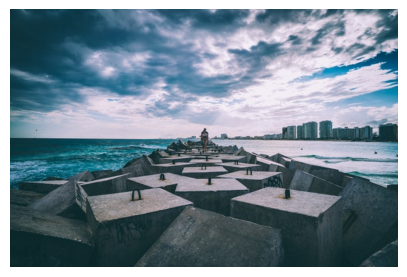

In [16]:
# 이미지 2 실행
inference(model2, image_path+"image02.jpg")

Labrador_retriever: 69.06%
golden_retriever: 9.57%
vizsla: 0.53%
redbone: 0.29%
Chesapeake_Bay_retriever: 0.26%


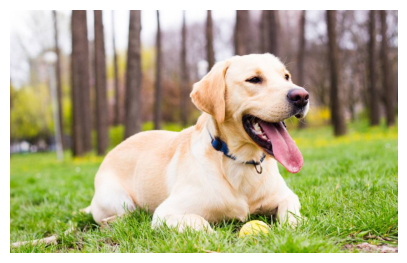

In [17]:
# 이미지 3 실행
inference(model2, image_path+"image03.jpg")

cocker_spaniel: 36.04%
English_setter: 13.61%
cheetah: 7.28%
studio_couch: 6.29%
Maltese_dog: 2.71%


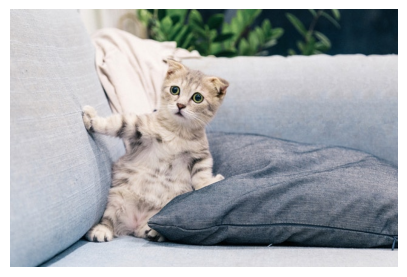

In [18]:
# 이미지 4 실행
inference(model2, image_path+"image04.jpg")